# MICCAI (Neuromorphometrics) atlas → ggsegpy

Pipeline:
1. Load Neuromorphometrics NIfTI + XML LUT (from SPM12)
2. Project volume → fsaverage pial surface (per hemi)
3. Per region per view (lateral / medial): build 2D polygon by projecting + unioning triangles
4. Assemble `core` + `2d` dataframes matching ggsegpy schema
5. Register `CorticalAtlas`, test plot

Schema (from `ggsegpy.atlases`):
- core: `label, hemi, region, color`
- 2d: `label, view, geometry_wkt` (merged with core on `label`)

In [3]:
from pathlib import Path
import importlib.resources as ir

import numpy as np
import pandas as pd
import geopandas as gpd
import nibabel as nib
from nilearn import datasets, surface
from shapely.geometry import Polygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt

## Step 1 — paths

Use atlasreader bundled files (no SPM install needed):
- `<atlasreader>/data/atlases/atlas_neuromorphometrics.nii.gz`
- `<atlasreader>/data/atlases/labels_neuromorphometrics.csv` (CSV: `index,name`)

Note: `import atlasreader` currently breaks in this env (nilearn API drift on `check_niimg`). Doesn't matter — locate files via `importlib.resources` without importing the package.

In [4]:
from importlib.util import find_spec

spec = find_spec("atlasreader")
assert spec and spec.submodule_search_locations, "atlasreader not installed"
DATA_DIR = Path(spec.submodule_search_locations[0]) / "data" / "atlases"

ATLAS_NII = DATA_DIR / "atlas_neuromorphometrics.nii.gz"
ATLAS_CSV = DATA_DIR / "labels_neuromorphometrics.csv"
OUT_DIR   = Path("./miccai_ggseg")
OUT_DIR.mkdir(exist_ok=True)
assert ATLAS_NII.exists(), ATLAS_NII
assert ATLAS_CSV.exists(), ATLAS_CSV
ATLAS_NII, ATLAS_CSV

(PosixPath('/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/atlasreader/data/atlases/atlas_neuromorphometrics.nii.gz'),
 PosixPath('/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/atlasreader/data/atlases/labels_neuromorphometrics.csv'))

## Step 2 — parse LUT

CSV has `index,name`. Names like `Left_Foo` / `Right_Foo` give hemi; midline structures (3rd_Ventricle, Brain_Stem, etc.) tagged `midline` and skipped for cortical atlas.

In [5]:
SUBCORTICAL_TOKENS = (
    "ventricle", "accumbens", "amygdala", "brain_stem", "caudate",
    "cerebellum", "white_matter", "csf", "hippocampus", "inf_lat_vent",
    "pallidum", "putamen", "thalamus", "ventral_dc", "vessel",
    "optic_chiasm", "basal_forebrain", "choroid_plexus",
)

def is_cortical(region: str) -> bool:
    low = region.lower()
    return not any(tok in low for tok in SUBCORTICAL_TOKENS)

def parse_lut(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    rows = []
    for _, r in df.iterrows():
        name = r["name"].strip()
        low = name.lower()
        if low.startswith("left_"):
            hemi, region = "left", name[5:]
        elif low.startswith("right_"):
            hemi, region = "right", name[6:]
        else:
            hemi, region = "midline", name
        rows.append({"id": int(r["index"]), "name": name, "hemi": hemi, "region": region})
    out = pd.DataFrame(rows)
    out = out[out["region"].apply(is_cortical) & (out["hemi"] != "midline")].reset_index(drop=True)
    return out

lut = parse_lut(ATLAS_CSV)
print(len(lut), "cortical labels")
lut.head()

98 cortical labels


,id,name,hemi,region
0,100,Right_ACgG_anterior_cingulate_gyrus,right,ACgG_anterior_cingulate_gyrus
1,101,Left_ACgG_anterior_cingulate_gyrus,left,ACgG_anterior_cingulate_gyrus
2,102,Right_AIns_anterior_insula,right,AIns_anterior_insula
3,103,Left_AIns_anterior_insula,left,AIns_anterior_insula
4,104,Right_AOrG_anterior_orbital_gyrus,right,AOrG_anterior_orbital_gyrus


## Step 3 — project volume to fsaverage surface

Sample on **pial** (where cortex actually is in volume), use **inflated** vertex coords for 2D viz. Same vertex indexing on both meshes, so labels transfer directly. Wider `radius` reduces unsampled (label=0) vertices. Full `fsaverage` (~163k verts) gives smooth borders.

In [6]:
from collections import Counter

fs = datasets.fetch_surf_fsaverage("fsaverage")
atlas_img = nib.load(str(ATLAS_NII))

lab_lh = surface.vol_to_surf(
    atlas_img, fs.pial_left, interpolation="nearest_most_frequent", radius=3.0
).astype(int)
lab_rh = surface.vol_to_surf(
    atlas_img, fs.pial_right, interpolation="nearest_most_frequent", radius=3.0
).astype(int)

verts_lh, faces_lh = surface.load_surf_mesh(fs.infl_left)
verts_rh, faces_rh = surface.load_surf_mesh(fs.infl_right)

# Mask vertices whose label is not in cortical LUT → 0, then fill from cortical neighbours.
cortical_ids = set(lut["id"].astype(int).tolist())

def mask_noncortical(labels):
    out = labels.copy()
    out[~np.isin(out, list(cortical_ids))] = 0
    return out

def vertex_neighbours(faces, n_verts):
    nbrs = [set() for _ in range(n_verts)]
    for a, b, c in faces:
        nbrs[a].update((b, c))
        nbrs[b].update((a, c))
        nbrs[c].update((a, b))
    return [np.fromiter(s, dtype=int) for s in nbrs]

def fill_zero_labels(labels, faces, n_iter=20):
    labels = labels.copy()
    nbrs = vertex_neighbours(faces, len(labels))
    for _ in range(n_iter):
        zero_idx = np.where(labels == 0)[0]
        if len(zero_idx) == 0:
            break
        new = labels.copy()
        for v in zero_idx:
            nb_lab = labels[nbrs[v]]
            nb_lab = nb_lab[nb_lab != 0]
            if len(nb_lab):
                new[v] = Counter(nb_lab).most_common(1)[0][0]
        if np.array_equal(new, labels):
            break
        labels = new
    return labels

lab_lh = fill_zero_labels(mask_noncortical(lab_lh), faces_lh)
lab_rh = fill_zero_labels(mask_noncortical(lab_rh), faces_rh)
print("remaining zeros lh/rh:", (lab_lh == 0).sum(), (lab_rh == 0).sum())

[fetch_surf_fsaverage] Dataset found in /Users/daniel/nilearn_data/fsaverage

remaining zeros lh/rh: 3300 3392


## Step 4 — 2D polygons per region per view

Per hemi+view:
- 2D coords = (y, z)
- Cull faces by normal x-component:
  - lh lateral: nx<0; lh medial: nx>0
  - rh lateral: nx>0; rh medial: nx<0
- Region polygon = union of visible triangles whose 3 vertices share label.

In [7]:
from shapely.geometry import MultiPolygon

def face_normals(verts, faces):
    v0 = verts[faces[:, 0]]
    v1 = verts[faces[:, 1]]
    v2 = verts[faces[:, 2]]
    return np.cross(v1 - v0, v2 - v0)

def majority_label(triplet):
    a, b, c = triplet
    if a == b or a == c:
        return a
    if b == c:
        return b
    return a  # all different — pick first; rare

def drop_holes(g):
    if g.is_empty:
        return g
    if g.geom_type == "Polygon":
        return Polygon(g.exterior)
    if g.geom_type == "MultiPolygon":
        return MultiPolygon([Polygon(p.exterior) for p in g.geoms if not p.is_empty])
    return g

def region_polygons(verts, faces, vlabels, side_sign,
                    close_radius=3.0, simplify_tol=0.5):
    n = face_normals(verts, faces)
    keep = (n[:, 0] * side_sign) > 0
    f_keep = faces[keep]
    f_lab = vlabels[f_keep]
    # majority label per face
    f_id = np.array([majority_label(t) for t in f_lab])

    polys = {}
    for lab_id in np.unique(f_id):
        if lab_id == 0:
            continue
        tri_idx = f_keep[f_id == lab_id]
        tris = [Polygon(verts[t][:, [1, 2]]) for t in tri_idx]
        tris = [t for t in tris if t.is_valid and t.area > 0]
        if not tris:
            continue
        geom = unary_union(tris).buffer(close_radius).buffer(-close_radius)
        geom = drop_holes(geom)
        if simplify_tol:
            geom = geom.simplify(simplify_tol, preserve_topology=True)
        if geom.is_empty:
            continue
        polys[int(lab_id)] = geom
    return polys

polys_lh_lat = region_polygons(verts_lh, faces_lh, lab_lh, side_sign=-1)
polys_lh_med = region_polygons(verts_lh, faces_lh, lab_lh, side_sign=+1)
polys_rh_lat = region_polygons(verts_rh, faces_rh, lab_rh, side_sign=+1)
polys_rh_med = region_polygons(verts_rh, faces_rh, lab_rh, side_sign=-1)
len(polys_lh_lat), len(polys_rh_lat)

(34, 35)

Sanity plot.

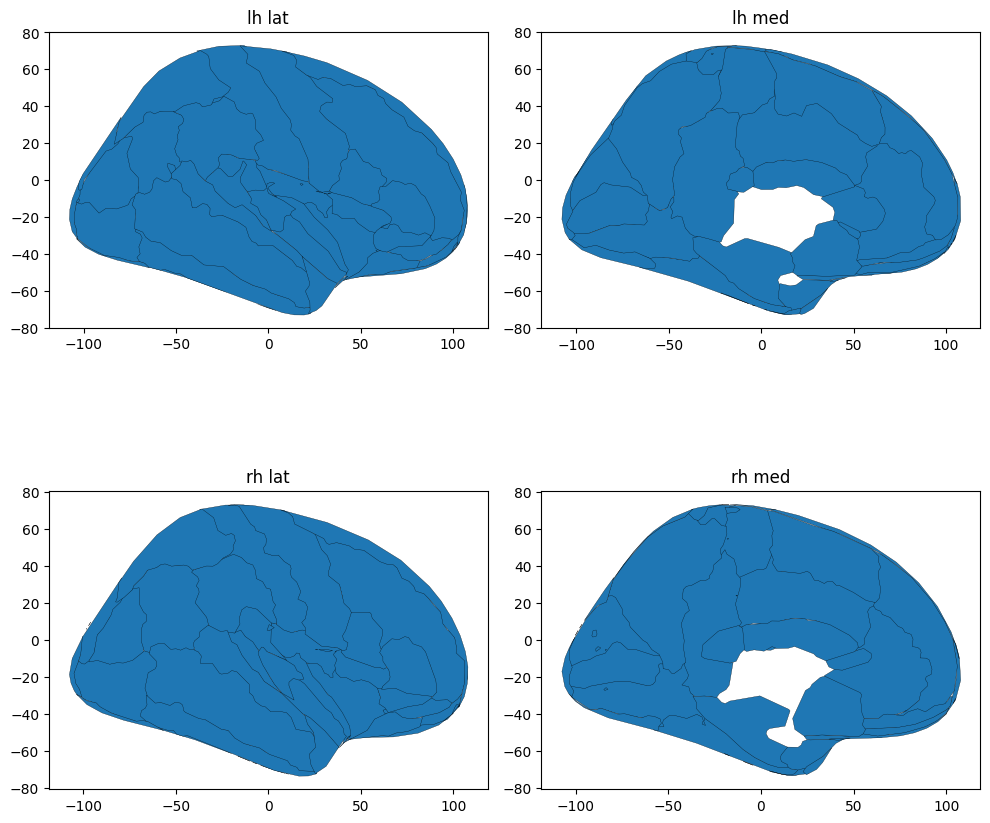

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, polys, title in zip(
    axes.ravel(),
    [polys_lh_lat, polys_lh_med, polys_rh_lat, polys_rh_med],
    ["lh lat", "lh med", "rh lat", "rh med"],
):
    for geom in polys.values():
        gpd.GeoSeries([geom]).plot(ax=ax, edgecolor="k", linewidth=0.2)
    ax.set_aspect("equal"); ax.set_title(title)
plt.tight_layout()

## Step 5 — assemble dataframes

ggsegpy `label`: `lh_<region>` / `rh_<region>`. View names: `lateral`, `medial`. `slug` collapses spaces/punctuation so labels are valid identifiers.

In [11]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def slug(s: str) -> str:
    return s.lower().replace(" ", "").replace("-", "").replace(".", "")

lut_idx = lut.set_index("id")

rows_2d = []
def add(polys, hemi, view):
    prefix = "lh" if hemi == "left" else "rh"
    for lab_id, geom in polys.items():
        if lab_id not in lut_idx.index:
            continue
        meta = lut_idx.loc[lab_id]
        if meta.hemi != hemi:
            continue
        region = slug(meta.region)
        rows_2d.append({
            "label": f"{prefix}_{region}",
            "view": view,
            "geometry_wkt": geom.wkt,
        })

add(polys_lh_lat, "left",  "lateral")
add(polys_lh_med, "left",  "medial")
add(polys_rh_lat, "right", "lateral")
add(polys_rh_med, "right", "medial")

df_2d = pd.DataFrame(rows_2d)
df_2d.head()

,label,view,geometry_wkt
0,lh_ains_anterior_insula,lateral,POLYGON ((17.442267938928158 -11.9661384797411...
1,lh_aorg_anterior_orbital_gyrus,lateral,POLYGON ((76.47938310584084 -45.71775846500495...
2,lh_ang_angular_gyrus,lateral,POLYGON ((-79.52608434673412 21.46665748657605...
3,lh_co_central_operculum,lateral,POLYGON ((-7.9043514594599085 8.20215529689073...
4,lh_ent_entorhinal_area,lateral,POLYGON ((35.87702165543691 -58.18304149519486...


In [12]:
labels_present = sorted(df_2d["label"].unique())
core_rows = []
for i, lab in enumerate(labels_present):
    hemi = "left" if lab.startswith("lh_") else "right"
    region = lab[3:]
    color = mcolors.to_hex(mcolors.hsv_to_rgb(((i * 0.1763) % 1.0, 0.55, 0.85)))
    core_rows.append({"label": lab, "hemi": hemi, "region": region, "color": color})
core = pd.DataFrame(core_rows)
core.head()

,label,hemi,region,color
0,lh_acgg_anterior_cingulate_gyrus,left,acgg_anterior_cingulate_gyrus,#d96262
1,lh_ains_anterior_insula,left,ains_anterior_insula,#d2d962
2,lh_ang_angular_gyrus,left,ang_angular_gyrus,#62d96f
3,lh_aorg_anterior_orbital_gyrus,left,aorg_anterior_orbital_gyrus,#62c4d9
4,lh_calc_calcarine_cortex,left,calc_calcarine_cortex,#7d62d9


In [13]:
df_2d.to_parquet(OUT_DIR / "miccai_2d.parquet")
core.to_parquet(OUT_DIR / "miccai_core.parquet")
list(OUT_DIR.iterdir())

[PosixPath('miccai_ggseg/miccai_2d.parquet'),
 PosixPath('miccai_ggseg/frauscher_core.parquet'),
 PosixPath('miccai_ggseg/miccai_core.parquet'),
 PosixPath('miccai_ggseg/frauscher_2d.parquet')]

In [14]:
import shutil
PESCO_DATA = Path("../pesco/pesco/atlases/data").resolve()
PESCO_DATA.mkdir(parents=True, exist_ok=True)
for f in ["miccai_2d.parquet", "miccai_core.parquet"]:
    shutil.copy(OUT_DIR / f, PESCO_DATA / f)
print("copied to", PESCO_DATA, "→", sorted(p.name for p in PESCO_DATA.iterdir()))

copied to /Users/daniel/PhD/spectral-comparison/code/pesco/pesco/atlases/data → ['frauscher_2d.parquet', 'frauscher_core.parquet', 'miccai_2d.parquet', 'miccai_core.parquet']


## Step 7 — Frauscher 38-region atlas

Aggregate MICCAI polygons into Frauscher regions per `frauscher_region_map` (columns: `Region, Region name, Lobe, Hemisphere, source_labels, mapping_type`). `source_labels` already use `lh_<slug>` / `rh_<slug>` matching MICCAI atlas labels — direct lookup.

## Step 6 — register + test plot

Build `CorticalAtlas` directly (skip `ggsegpy.atlases` auto-loader; only knows dk/aseg/tracula).

In [15]:
from shapely import wkt
from ggsegpy.atlas import CorticalAtlas
from ggsegpy.data import CorticalData

df = pd.read_parquet(OUT_DIR / "miccai_2d.parquet")
df["geometry"] = df["geometry_wkt"].apply(wkt.loads)
df = df.drop(columns=["geometry_wkt"]).merge(core, on="label", how="left")
ggseg2d = gpd.GeoDataFrame(df, geometry="geometry")

ggseg3d_empty = pd.DataFrame({"label": pd.Series(dtype=str),
                              "vertex_indices": pd.Series(dtype=object)})

miccai = CorticalAtlas(
    atlas="miccai",
    type="cortical",
    core=core,
    data=CorticalData(ggseg=ggseg2d, ggseg3d=ggseg3d_empty, mesh=None),
    palette=dict(zip(core["label"], core["color"])),
)
miccai

CorticalAtlas(atlas='miccai', type='cortical', core=                                                label   hemi  \
0                    lh_acgg_anterior_cingulate_gyrus   left   
1                             lh_ains_anterior_insula   left   
2                                lh_ang_angular_gyrus   left   
3                      lh_aorg_anterior_orbital_gyrus   left   
4                            lh_calc_calcarine_cortex   left   
..                                                ...    ...   
93                    rh_spl_superior_parietal_lobule  right   
94                     rh_stg_superior_temporal_gyrus  right   
95                               rh_tmp_temporal_pole  right   
96  rh_trifg_triangular_part_of_the_inferior_front...  right   
97                   rh_ttg_transverse_temporal_gyrus  right   

                                               region    color  
0                       acgg_anterior_cingulate_gyrus  #d96262  
1                                ains_anterior_in

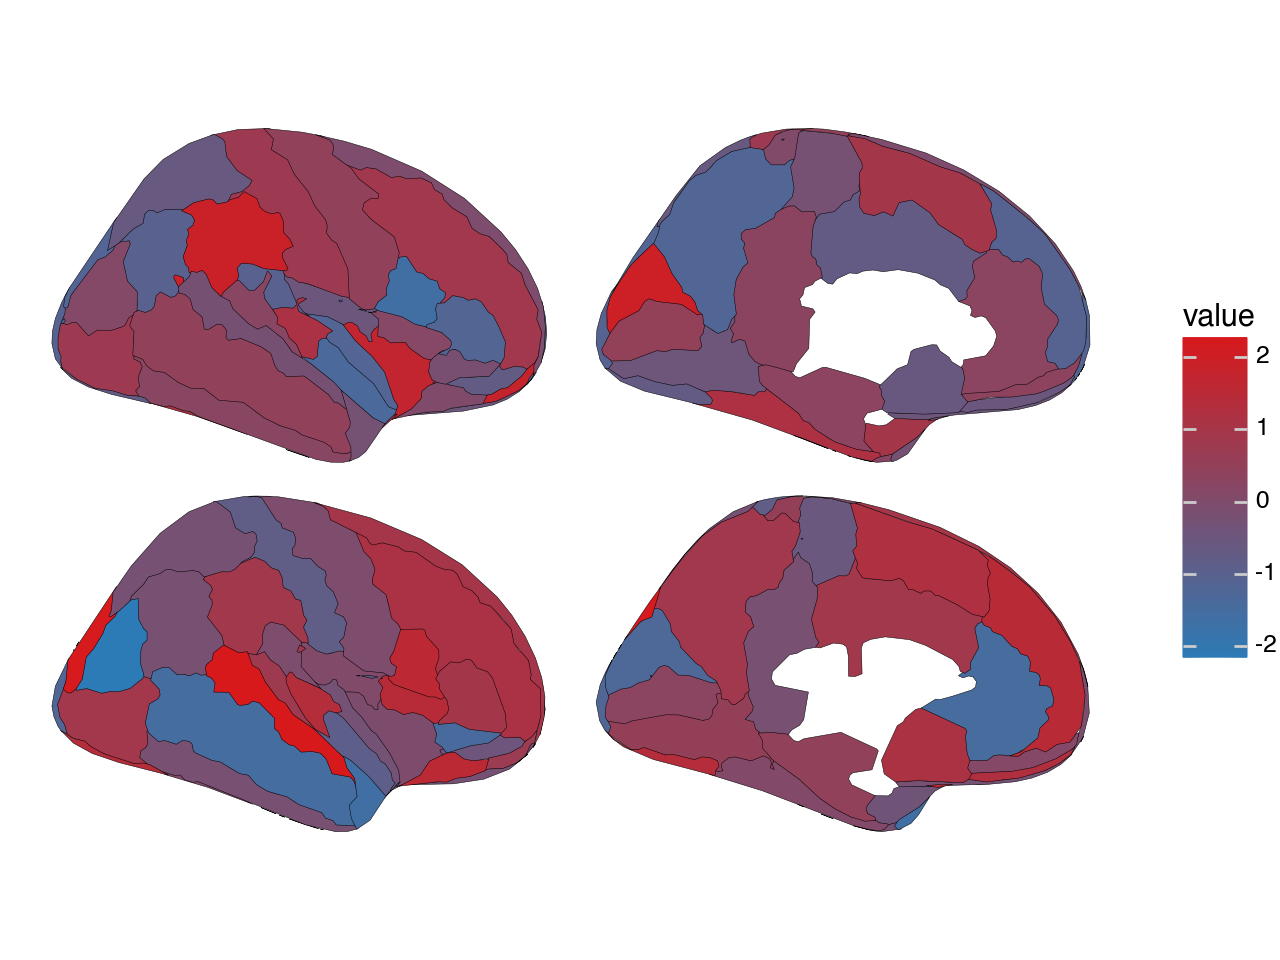

In [16]:
from ggsegpy.geom_brain import geom_brain
from plotnine import ggplot, aes, theme_void, scale_fill_gradient

vals = core[["label"]].copy()
vals["value"] = np.random.randn(len(vals))

(
    ggplot(vals, aes(fill="value"))
    + geom_brain(atlas=miccai, mapping=aes(fill="value"))
    + scale_fill_gradient(low="#2c7bb6", high="#d7191c")
    + theme_void()
)

In [17]:
import pandas as pd

base_mapping = [
    (1,  "Superior and middle occipital gyri", "Occipital",
     ["sog_superior_occipital_gyrus", "mog_middle_occipital_gyrus"], "joined"),

    (2,  "Inferior occipital gyrus and occipital pole", "Occipital",
     ["iog_inferior_occipital_gyrus", "ocp_occipital_pole"], "joined"),

    (3,  "Cuneus", "Occipital",
     ["cun_cuneus"], "single"),

    (4,  "Calcarine cortex", "Occipital",
     ["calc_calcarine_cortex"], "single"),

    (5,  "Lingual gyrus and occipital fusiform gyrus", "Occipital",
     ["lig_lingual_gyrus", "ofug_occipital_fusiform_gyrus"], "joined"),

    (6,  "Postcentral gyrus (including medial segment)", "Parietal",
     ["pog_postcentral_gyrus", "mpog_postcentral_gyrus_medial_segment"], "joined"),

    (7,  "Superior parietal lobule", "Parietal",
     ["spl_superior_parietal_lobule"], "single"),

    (8,  "Parietal operculum", "Parietal",
     ["po_parietal_operculum"], "single"),

    (9,  "Supramarginal gyrus", "Parietal",
     ["smg_supramarginal_gyrus"], "single"),

    (10, "Angular gyrus", "Parietal",
     ["ang_angular_gyrus"], "single"),

    (11, "Precuneus", "Parietal",
     ["pcu_precuneus"], "single"),

    (12, "Posterior cingulate", "Parietal",
     ["pcgg_posterior_cingulate_gyrus"], "single"),

    (13, "Anterior insula", "Insula",
     ["ains_anterior_insula"], "single"),

    (14, "Posterior insula", "Insula",
     ["pins_posterior_insula"], "single"),

    (15, "Gyrus rectus and orbital gyri", "Frontal",
     [
         "gre_gyrus_rectus",
         "aorg_anterior_orbital_gyrus",
         "morg_medial_orbital_gyrus",
         "porg_posterior_orbital_gyrus",
         "lorg_lateral_orbital_gyrus",
     ], "joined"),

    (16, "Anterior cingulate", "Frontal",
     ["acgg_anterior_cingulate_gyrus"], "single"),

    (17, "Middle cingulate", "Frontal",
     ["mcgg_middle_cingulate_gyrus"], "single"),

    (18, "Supplementary motor cortex", "Frontal",
     ["smc_supplementary_motor_cortex"], "single"),

    (19, "Medial frontal cortex", "Frontal",
     ["mfc_medial_frontal_cortex"], "single"),

    (20, "Central operculum", "Frontal",
     ["co_central_operculum"], "single"),

    (21, "Frontal operculum", "Frontal",
     ["fo_frontal_operculum"], "single"),

    (22, "Opercular part of inferior frontal gyrus", "Frontal",
     ["opifg_opercular_part_of_the_inferior_frontal_gyrus"], "single"),

    (23, "Triangular part of inferior frontal gyrus", "Frontal",
     ["trifg_triangular_part_of_the_inferior_frontal_gyrus"], "single"),

    (24, "Orbital part of inferior frontal gyrus", "Frontal",
     ["orifg_orbital_part_of_the_inferior_frontal_gyrus"], "single"),

    (25, "Middle frontal gyrus", "Frontal",
     ["mfg_middle_frontal_gyrus"], "single"),

    (26, "Superior frontal gyrus and frontal pole", "Frontal",
     ["sfg_superior_frontal_gyrus", "frp_frontal_pole"], "joined"),

    (27, "Medial segment of superior frontal gyrus", "Frontal",
     ["msfg_superior_frontal_gyrus_medial_segment"], "single"),

    (28, "Medial segment of precentral gyrus", "Frontal",
     ["mprg_precentral_gyrus_medial_segment"], "single"),

    (29, "Precentral gyrus", "Frontal",
     ["prg_precentral_gyrus"], "single"),

    (30, "Superior temporal gyrus", "Temporal",
     ["stg_superior_temporal_gyrus"], "single"),

    (31, "Middle temporal gyrus", "Temporal",
     ["mtg_middle_temporal_gyrus"], "single"),

    (32, "Inferior temporal gyrus", "Temporal",
     ["itg_inferior_temporal_gyrus"], "single"),

    (33, "Temporal pole and planum polare", "Temporal",
     ["tmp_temporal_pole", "pp_planum_polare"], "joined"),

    (34, "Transverse temporal gyrus", "Temporal",
     ["ttg_transverse_temporal_gyrus"], "single"),

    (35, "Planum temporale", "Temporal",
     ["pt_planum_temporale"], "single"),

    (36, "Fusiform and parahippocampal gyri", "Temporal",
     ["fug_fusiform_gyrus", "phg_parahippocampal_gyrus"], "joined"),

    (37, "Hippocampus", "Temporal",
     ["hippocampus"], "subcortical_or_missing_from_palette"),

    (38, "Amygdala", "Temporal",
     ["amygdala"], "subcortical_or_missing_from_palette"),
]

rows = []

for region, region_name, lobe, source_labels_no_hemi, mapping_type in base_mapping:
    for hemi_prefix, hemisphere in [("lh", "L"), ("rh", "R")]:
        rows.append(
            {
                "Region": region,
                "Region name": region_name,
                "Lobe": lobe,
                "Hemisphere": hemisphere,
                "source_labels": [
                    f"{hemi_prefix}_{label}"
                    for label in source_labels_no_hemi
                ],
                "mapping_type": mapping_type,
            }
        )

frauscher_region_map = pd.DataFrame(rows)

frauscher_region_map

,Region,Region name,Lobe,Hemisphere,source_labels,mapping_type
0,1,Superior and middle occipital gyri,Occipital,L,"[lh_sog_superior_occipital_gyrus, lh_mog_middl...",joined
1,1,Superior and middle occipital gyri,Occipital,R,"[rh_sog_superior_occipital_gyrus, rh_mog_middl...",joined
2,2,Inferior occipital gyrus and occipital pole,Occipital,L,"[lh_iog_inferior_occipital_gyrus, lh_ocp_occip...",joined
3,2,Inferior occipital gyrus and occipital pole,Occipital,R,"[rh_iog_inferior_occipital_gyrus, rh_ocp_occip...",joined
4,3,Cuneus,Occipital,L,[lh_cun_cuneus],single
...,...,...,...,...,...,...
71,36,Fusiform and parahippocampal gyri,Temporal,R,"[rh_fug_fusiform_gyrus, rh_phg_parahippocampal...",joined
72,37,Hippocampus,Temporal,L,[lh_hippocampus],subcortical_or_missing_from_palette
73,37,Hippocampus,Temporal,R,[rh_hippocampus],subcortical_or_missing_from_palette
74,38,Amygdala,Temporal,L,[lh_amygdala],subcortical_or_missing_from_palette


In [18]:
import re

def slug_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

# fast lookup for MICCAI polygons by (label, view)
miccai_polys = {(r["label"], r["view"]): r["geometry"] for _, r in ggseg2d.iterrows()}

agg_rows, core_rows, missing = [], [], []
for _, fr in frauscher_region_map.iterrows():
    rid = int(fr["Region"])
    hemi_prefix = "lh" if fr["Hemisphere"] == "L" else "rh"
    hemi_full = "left" if fr["Hemisphere"] == "L" else "right"
    label = f"{hemi_prefix}_r{rid:02d}"
    region = slug_name(fr["Region name"])

    for view in ("lateral", "medial"):
        members = [
            miccai_polys[(src, view)]
            for src in fr["source_labels"]
            if (src, view) in miccai_polys and not miccai_polys[(src, view)].is_empty
        ]
        if not members:
            missing.append((label, view, list(fr["source_labels"])))
            continue
        merged = unary_union(members)
        agg_rows.append({"label": label, "view": view, "geometry_wkt": merged.wkt})

    core_rows.append({"label": label, "hemi": hemi_full, "region": region,
                      "lobe": fr["Lobe"], "frauscher_id": rid})

frauscher_2d = pd.DataFrame(agg_rows)
frauscher_core = pd.DataFrame(core_rows).drop_duplicates("label").reset_index(drop=True)
n = len(frauscher_core)
frauscher_core["color"] = [
    mcolors.to_hex(mcolors.hsv_to_rgb(((i * 0.1763) % 1.0, 0.55, 0.85)))
    for i in range(n)
]
print(len(frauscher_2d), "polygons,", n, "regions; missing entries:", len(missing))
missing[:5]

97 polygons, 76 regions; missing entries: 55


[('lh_r03', 'lateral', ['lh_cun_cuneus']),
 ('lh_r04', 'lateral', ['lh_calc_calcarine_cortex']),
 ('rh_r04', 'lateral', ['rh_calc_calcarine_cortex']),
 ('lh_r08', 'medial', ['lh_po_parietal_operculum']),
 ('rh_r08', 'medial', ['rh_po_parietal_operculum'])]

In [19]:
frauscher_2d.to_parquet(OUT_DIR / "frauscher_2d.parquet")
frauscher_core.to_parquet(OUT_DIR / "frauscher_core.parquet")

for f in ["frauscher_2d.parquet", "frauscher_core.parquet"]:
    shutil.copy(OUT_DIR / f, PESCO_DATA / f)
print("saved + copied to", PESCO_DATA)

saved + copied to /Users/daniel/PhD/spectral-comparison/code/pesco/pesco/atlases/data


/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.14/site-packages/ggsegpy/geom_brain.py:70: UserWarning: Data contains values not in atlas 'label' column: {'lh_r37', 'rh_r38', 'lh_r38', 'rh_r37'}


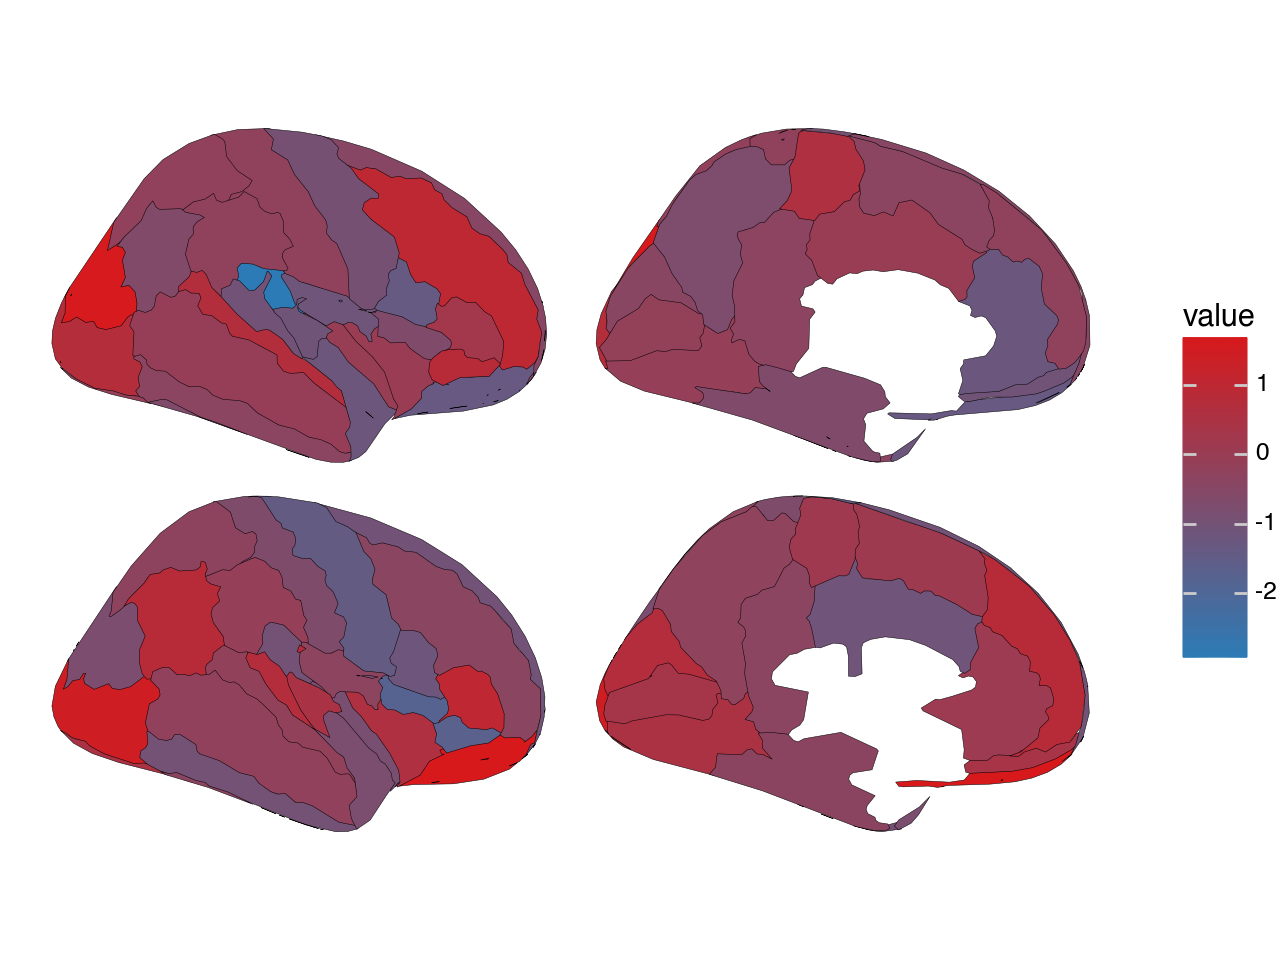

In [20]:
df = frauscher_2d.copy()
df["geometry"] = df["geometry_wkt"].apply(wkt.loads)
df = df.drop(columns=["geometry_wkt"]).merge(frauscher_core, on="label", how="left")
fr_ggseg2d = gpd.GeoDataFrame(df, geometry="geometry")

frauscher_atlas = CorticalAtlas(
    atlas="frauscher38",
    type="cortical",
    core=frauscher_core,
    data=CorticalData(ggseg=fr_ggseg2d, ggseg3d=ggseg3d_empty, mesh=None),
    palette=dict(zip(frauscher_core["label"], frauscher_core["color"])),
)

vals = frauscher_core[["label"]].copy()
vals["value"] = np.random.randn(len(vals))

(
    ggplot(vals, aes(fill="value"))
    + geom_brain(atlas=frauscher_atlas, mapping=aes(fill="value"))
    + scale_fill_gradient(low="#2c7bb6", high="#d7191c")
    + theme_void()
)